In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import os


In [2]:
BASE_PATH = r"C:\Users\Agastya\Hbb-jet-tagging"

TRAIN_NPZ = BASE_PATH + r"\data\processed\train.npz"
VAL_NPZ   = BASE_PATH + r"\data\processed\val.npz"
MODEL_OUT = BASE_PATH + r"\artifacts\mlp.pt"


In [3]:
train_data = np.load(TRAIN_NPZ)
val_data   = np.load(VAL_NPZ)

X_train = train_data["X"]
y_train = train_data["y"]

X_val = val_data["X"]
y_val = val_data["y"]

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)


(159768, 12) (159768,)
(39943, 12) (39943,)


In [4]:
class JetDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [5]:
BATCH_SIZE = 1024

train_ds = JetDataset(X_train, y_train)
val_ds   = JetDataset(X_val, y_val)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)


In [6]:
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = MLP(input_dim=X_train.shape[1]).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


Using device: cuda


In [8]:
EPOCHS = 30

best_auc = 0.0

for epoch in range(1, EPOCHS + 1):
    # ---- TRAIN ----
    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)

    train_loss /= len(train_loader.dataset)

    # ---- VALIDATE ----
    model.eval()
    val_logits = []

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            logits = model(xb)
            val_logits.append(logits.cpu())

    val_logits = torch.cat(val_logits)
    val_probs = torch.sigmoid(val_logits).numpy()

    val_auc = roc_auc_score(y_val, val_probs)

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val AUC: {val_auc:.4f}"
    )

    # ---- SAVE BEST ----
    if val_auc > best_auc:
        best_auc = val_auc
        torch.save(model.state_dict(), MODEL_OUT)


Epoch 01 | Train Loss: 0.2708 | Val AUC: 0.9527
Epoch 02 | Train Loss: 0.1787 | Val AUC: 0.9577
Epoch 03 | Train Loss: 0.1697 | Val AUC: 0.9614
Epoch 04 | Train Loss: 0.1646 | Val AUC: 0.9636
Epoch 05 | Train Loss: 0.1618 | Val AUC: 0.9648
Epoch 06 | Train Loss: 0.1587 | Val AUC: 0.9652
Epoch 07 | Train Loss: 0.1567 | Val AUC: 0.9664
Epoch 08 | Train Loss: 0.1541 | Val AUC: 0.9671
Epoch 09 | Train Loss: 0.1526 | Val AUC: 0.9674
Epoch 10 | Train Loss: 0.1508 | Val AUC: 0.9677
Epoch 11 | Train Loss: 0.1508 | Val AUC: 0.9684
Epoch 12 | Train Loss: 0.1495 | Val AUC: 0.9686
Epoch 13 | Train Loss: 0.1487 | Val AUC: 0.9686
Epoch 14 | Train Loss: 0.1482 | Val AUC: 0.9688
Epoch 15 | Train Loss: 0.1481 | Val AUC: 0.9689
Epoch 16 | Train Loss: 0.1477 | Val AUC: 0.9689
Epoch 17 | Train Loss: 0.1462 | Val AUC: 0.9693
Epoch 18 | Train Loss: 0.1467 | Val AUC: 0.9694
Epoch 19 | Train Loss: 0.1468 | Val AUC: 0.9690
Epoch 20 | Train Loss: 0.1459 | Val AUC: 0.9684
Epoch 21 | Train Loss: 0.1460 | Val AUC:

Best MLP model loaded with AUC: 0.9700042198385512


C:\Users\Agastya\AppData\Local\Temp\ipykernel_3928\53782221.py:10: RuntimeWarning: divide by zero encountered in divide
  plt.plot(tpr, 1 / fpr, label=f"MLP AUC = {best_auc:.3f}")


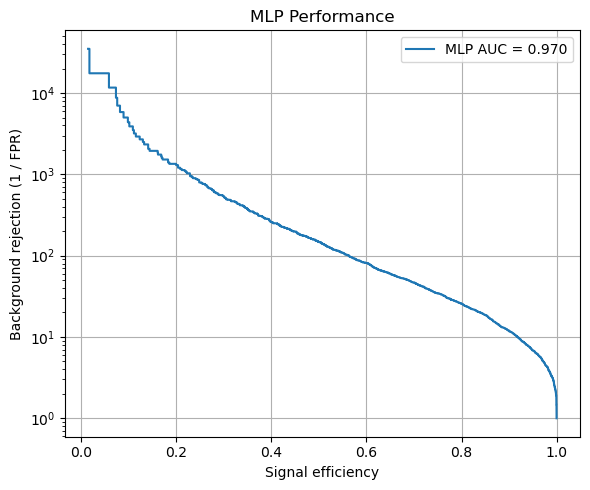

In [9]:
model.load_state_dict(torch.load(MODEL_OUT))
model.eval()

print("Best MLP model loaded with AUC:", best_auc)


fpr, tpr, _ = roc_curve(y_val, val_probs)

plt.figure(figsize=(6, 5))
plt.plot(tpr, 1 / fpr, label=f"MLP AUC = {best_auc:.3f}")
plt.yscale("log")
plt.xlabel("Signal efficiency")
plt.ylabel("Background rejection (1 / FPR)")
plt.grid(True)
plt.legend()
plt.title("MLP Performance")
plt.tight_layout()
plt.show()

